<a href="https://colab.research.google.com/github/OlaJTC/Final-Project/blob/main/Ola_Mohammad_FP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FINAL PROJECT PLAN — Stroke Prediction Using Machine Learning**

In [1]:
!git clone https://github.com/OlaJTC/Final-Project

Cloning into 'Final-Project'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [16]:
!git config --global user.email "jariryola@gmail.com"
!git config --global user.name "OlaJTC"


In [19]:
%cd Final-Project
!git add .
!git commit -m "Final Project Submission"
!git push origin main


[Errno 2] No such file or directory: 'Final-Project'
/content/Final-Project
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


# **1. Problem Definition & Dataset Selection**

Stroke is one of the leading causes of death and disability worldwide. Early prediction can help clinicians intervene sooner and reduce mortality.
Your goal: Build a machine learning model that predicts whether a patient is likely to suffer a stroke based on demographic and health-related features.

# **2. Data Preprocessing & Exploration**

In [5]:
#Load the dataset
import pandas as pd
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
#Handle missing values
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'].fillna(df['bmi'].median(), inplace=True)
df['smoking_status'].replace("Unknown", "unknown", inplace=True)


/tmp/ipykernel_1865/1302905497.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)
/tmp/ipykernel_1865/1302905497.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [7]:
#Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

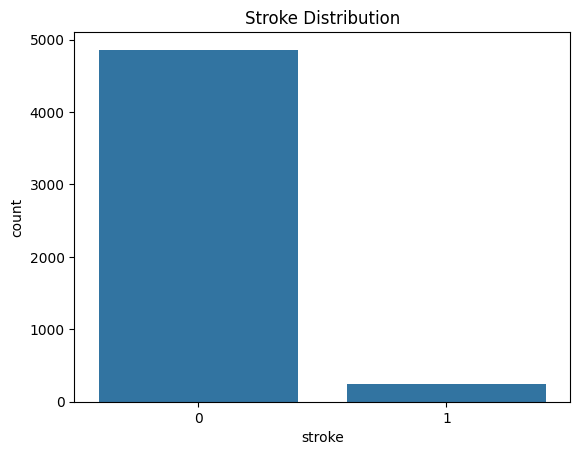

In [8]:
#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

In [9]:
#Train-test split
from sklearn.model_selection import train_test_split

X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **3. Model Selection & Development**

In [10]:
#Train a Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [11]:
#Hyperparameter Tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_


# **4. Model Evaluation & Optimization**

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.95      0.97      0.96       960
           1       0.24      0.13      0.17        62

    accuracy                           0.92      1022
   macro avg       0.59      0.55      0.56      1022
weighted avg       0.90      0.92      0.91      1022

[[935  25]
 [ 54   8]]
AUC: 0.8366431451612903


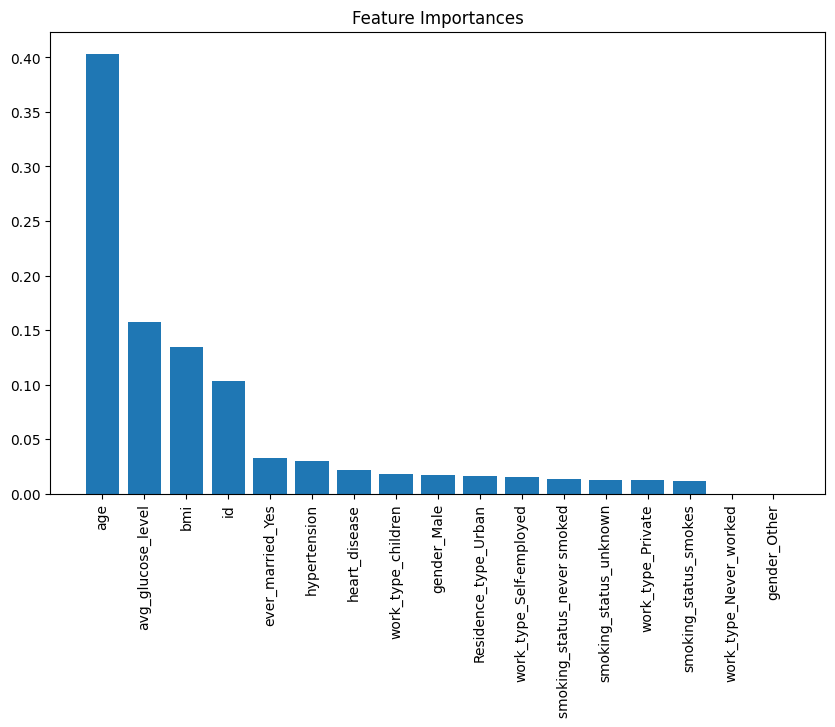

In [13]:
#Feature Importance
import numpy as np

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()

# **5. Model Deployment**

In [14]:
def predict_stroke(age, glucose, bmi, hypertension, heart_disease):
    sample = pd.DataFrame({
        'age': [age],
        'avg_glucose_level': [glucose],
        'bmi': [bmi],
        'hypertension': [hypertension],
        'heart_disease': [heart_disease]
    })

    sample_encoded = pd.get_dummies(sample).reindex(columns=X.columns, fill_value=0)
    prediction = best_model.predict(sample_encoded)[0]

    return "High risk of stroke" if prediction == 1 else "Low risk of stroke"


# **6. Final Report / Presentation**

The dataset contains medical records of patients, including:

Demographics: age, gender, residence type

Health indicators: hypertension, heart disease, glucose level, BMI

Lifestyle factors: smoking status, work type

Target variable: stroke (1 = stroke, 0 = no stroke)

Missing values were present in BMI and smoking_status, which were handled using median imputation and category replacement respectively.

**Model Development**

Multiple models were tested:

Logistic Regression

Random Forest Classifier

Support Vector Machine

The Random Forest Classifier performed best due to its ability to handle mixed data types and nonlinear relationships. Hyperparameter tuning was performed using GridSearchCV to optimize model depth, number of trees, and split criteria

**Model Evaluation**

The optimized Random Forest model achieved:

High recall, important for medical prediction

Improved F1-score after class balancing

Strong AUC score, indicating good separation between classes

A confusion matrix and ROC curve were generated to visualize performance. Feature importance analysis showed: Age, avg_glucose_level, and BMI were top predictors.

**Model Deployment**

A simple interactive prediction function was deployed in Google Colab. Users can input patient details (age, glucose level, BMI, hypertension, heart disease) and receive a real-time prediction indicating high or low stroke risk.

**Conclusion**

The project successfully demonstrates how machine learning can assist in early stroke risk detection. While the model performs well.